# Notebook 1 — Extraction des features, preprocessing et analyse non supervisée
## Objectif du notebook

Ce notebook vise à préparer les données, extraire des embeddings via ResNet50, puis analyser leur structure à l’aide de méthodes non supervisées.


In [1]:
# Importe des bibliothèques principales
# pour explorer les données, manipuler les images et afficher les résultats.

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 1. Chargement des données

### Présentation du jeu de données
Dans cette étape, on commence par explorer la structure du jeu de données.

Les images sont organisées en deux ensembles :
- un ensemble labellisé, contenant des images classées en "cancer" et "normal"
- un ensemble non labellisé, qui sera utilisé plus tard dans l'approche semi-supervisée

L’objectif est de vérifier que les données sont bien accessibles, de comprendre leur organisation et de compter le nombre d’images disponibles dans chaque catégorie.

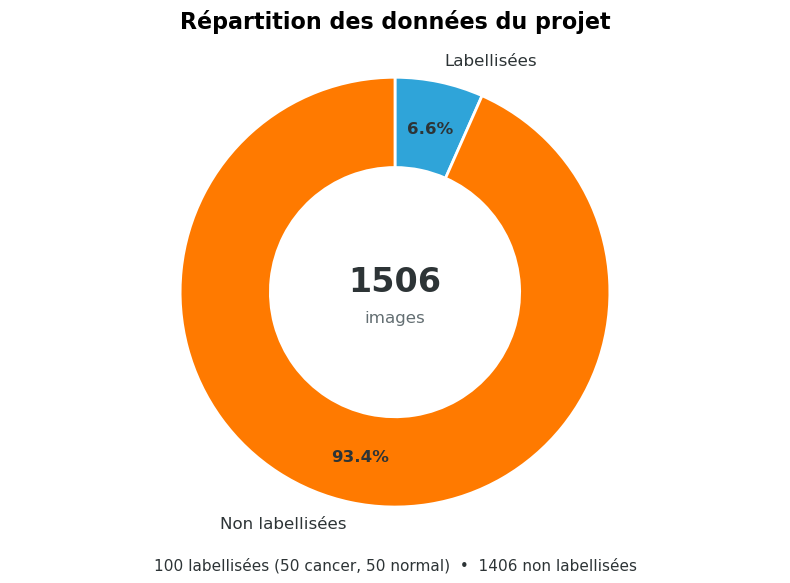

In [3]:
# Chemin racine des données
data_dir = Path("../data")

# Chemins vers les différentes parties du dataset
labeled_dir = data_dir / "avec_labels"
cancer_dir = labeled_dir / "cancer"
normal_dir = labeled_dir / "normal"

unlabeled_dir = data_dir / "sans_label"

# Fichiers images dans chaque dossier
cancer_images = sorted(cancer_dir.glob("*.jpg"))
normal_images = sorted(normal_dir.glob("*.jpg"))
unlabeled_images = sorted(unlabeled_dir.glob("*.jpg"))

# Comptage réel
n_cancer = len(cancer_images)
n_normal = len(normal_images)
n_labeled = n_cancer + n_normal
n_unlabeled = len(unlabeled_images)

sizes = [n_labeled, n_unlabeled]
labels = ["Labellisées", "Non labellisées"]
colors = ["#2fa4d9", "#ff7a00"]

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12, "color": "#2d3436"}
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")
    autotext.set_color("#2d3436")

# Texte central
ax.text(
    0, 0.05, f"{n_labeled + n_unlabeled}",
    ha="center", va="center", fontsize=24, fontweight="bold", color="#2d3436"
)
ax.text(
    0, -0.12, "images",
    ha="center", va="center", fontsize=12, color="#636e72"
)

ax.set_title("Répartition des données du projet", fontsize=16, fontweight="bold", pad=20)

fig.text(
    0.5, 0.04,
    f"{n_labeled} labellisées ({n_cancer} cancer, {n_normal} normal)  •  {n_unlabeled} non labellisées",
    ha="center",
    fontsize=11,
    color="#2d3436"
)

ax.axis("equal")
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

## Conclusion

Le jeu de données est correctement structuré, avec une séparation claire entre les données labellisées et non labellisées.

On dispose de deux classes équilibrées pour les données labellisées ("cancer" et "normal"), ainsi qu’un volume plus important de données non labellisées.

Cette configuration est adaptée à une approche semi-supervisée, où les données non labellisées pourront être exploitées pour améliorer les performances du modèle.

## 2. Visualisation et vérification des images

Avant de poursuivre le traitement des données, on vérifie que les images sont correctement lisibles et exploitables.

On affiche quelques exemples d’images pour chaque catégorie afin de :
- s’assurer qu’elles ne sont pas corrompues
- observer leur format et leur résolution
- identifier d’éventuelles différences visuelles entre les classes

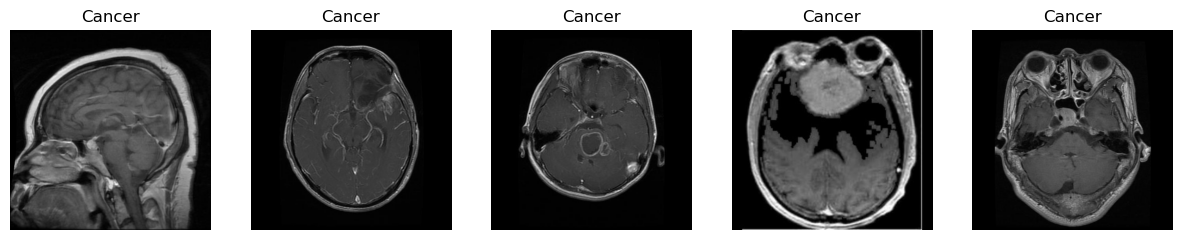

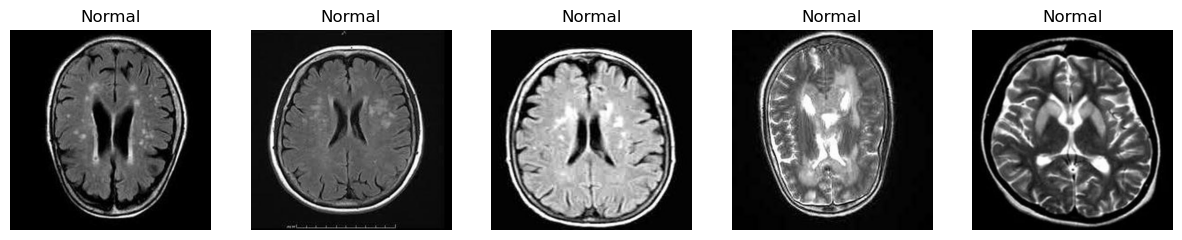

In [4]:
# Fonction pour afficher quelques images
def show_images(image_paths, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(image_paths[:n]):
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.show()


# Affichage d'exemples
show_images(cancer_images, "Cancer")
show_images(normal_images, "Normal")

In [5]:
# Combinaison de toutes les images du dataset
all_images = cancer_images + normal_images + unlabeled_images

# Stockage des tailles
sizes = set()

for img_path in all_images:
    try:
        img = Image.open(img_path)
        sizes.add(img.size)
    except Exception as e:
        print(f"Erreur avec {img_path} : {e}")

image_modes = set()

for img_path in all_images:
    try:
        img = Image.open(img_path)
        image_modes.add(img.mode)
    except Exception as e:
        print(f"Erreur avec {img_path} : {e}")

# Résultat
print("Tailles d'images trouvées :", sizes)
print("Modes d'image trouvés :", image_modes)
print("Nombre total d'images analysées :", len(all_images))

Tailles d'images trouvées : {(512, 512)}
Modes d'image trouvés : {'RGB'}
Nombre total d'images analysées : 1506


### Bilan de la qualité des images
Les images sont correctement lisibles et ne présentent pas d’anomalies visibles.

Elles sont en RGB, il n'y a donc pas besoin d’ajouter une conversion vers RGB dans la pipeline de prétraitement..

L’ensemble du dataset présente des dimensions homogènes (512x512), y compris les images non labellisées.

Aucune anomalie majeure n’a été détectée, ce qui confirme que les données sont cohérentes et exploitables pour la suite du projet.

Cette vérification réduit le risque d’erreurs lors des étapes de prétraitement et d’entraînement.

## 3. Prétraitement des images pour ResNet50
Dans cette étape, on prépare les images pour qu’elles puissent être utilisées par le modèle ResNet50 pré-entraîné.

Même si les images sont homogènes en 512x512, ResNet50 attend des images de taille 224x224 et une normalisation spécifique.

On va donc définir une pipeline de prétraitement qui :
- redimensionne les images
- convertit les images en tenseurs
- applique la normalisation attendue par le modèle

In [6]:
# Import des outils nécessaires pour préparer les images
# avant de les envoyer dans ResNet50.

import torch
from torchvision import transforms

# Définition de la transformation
# On redimensionne l'image en 224x224 car c'est le format attendu par ResNet50.
# On convertis ensuite l'image en tenseur PyTorch.
# Enfin, on applique la normalisation standard utilisée pour les modèles pré-entraînés sur ImageNet.
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(preprocess)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
# On teste sur une image pour vérifier que la sortie
# a bien la forme attendue par ResNet50.

sample_image = Image.open(cancer_images[0])
sample_tensor = preprocess(sample_image)

print("Shape du tenseur :", sample_tensor.shape)
print("Type :", type(sample_tensor))

Shape du tenseur : torch.Size([3, 224, 224])
Type : <class 'torch.Tensor'>


## 4. Préparation de l'extraction des features

ResNet50 est un réseau de neurones convolutif (CNN) composé de 50 couches, pré-entraîné sur le jeu de données ImageNet.

Dans sa version originale, ce modèle est conçu pour effectuer une classification parmi 1000 classes génériques (chien, chat, avion, etc.) en produisant un score de probabilité pour chaque classe.

Dans le cadre de ce projet, cet objectif de classification ne nous intéresse pas. Nous cherchons plutôt à exploiter la capacité du modèle à extraire des caractéristiques pertinentes à partir des images.

Pour cela, on supprime la couche finale de classification et on conserve uniquement la partie du réseau qui produit des embeddings. Ces embeddings correspondent à une représentation compacte et informative des images, que nous pourrons ensuite utiliser pour le clustering et l’apprentissage semi-supervisé.

In [8]:
# Import du modèle ResNet50 pré-entraîné depuis torchvision.
# Utilisé comme extracteur de features.

import torch.nn as nn
from torchvision import models

# Chargement des poids pré-entraînés sur ImageNet.
weights = models.ResNet50_Weights.DEFAULT
resnet50 = models.resnet50(weights=weights)

# Suppression de la couche finale de classification.
resnet50.fc = nn.Identity()

# Passage du modèle en mode évaluation.
# Cela désactive certains comportements spécifiques à l'entraînement, comme le dropout.
resnet50.eval()

print(resnet50)

0.6%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /tmp/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
# Test de l'extraction de features sur une image unique.
# Ajout d'une dimension batch avec unsqueeze(0), car le modèle attend
# un lot d'images et non une image seule.

sample_image = Image.open(cancer_images[0])
sample_tensor = preprocess(sample_image).unsqueeze(0)

with torch.no_grad():
    sample_features = resnet50(sample_tensor)

print("Shape des features :", sample_features.shape)
print("Type :", type(sample_features))

Shape des features : torch.Size([1, 2048])
Type : <class 'torch.Tensor'>


### Bilan de la préparation de l’extraction
On a chargé ResNet50 avec ses poids pré-entraînés sur ImageNet et on l’a transformé en extracteur de features en supprimant sa couche finale de classification.

Le test sur une image montre que le modèle produit un vecteur de 2048 caractéristiques. Ce vecteur constitue un embedding.

Cette sortie sera utilisée dans les étapes suivantes pour réduire la dimension des données, effectuer le clustering et construire l’approche semi-supervisée.

## 5. Extraction des features pour l’ensemble du dataset

Dans cette étape, on utilise ResNet50 comme extracteur de features pour transformer chaque image du dataset en embedding.

On réalise cette extraction sur toutes les images, labellisées et non labellisées, ces représentations seront ensuite utilisées pour la réduction de dimension, le clustering et l’apprentissage semi-supervisé.

Pour garder une exécution lisible et efficace, on traite les images par petits batchs et on sauvegarde les embeddings obtenus dans un fichier `.npy`.

In [10]:
# Cette fonction charge un petit groupe d'images, applique le prétraitement
# puis les empile dans un tenseur unique pour les envoyer au modèle.

def load_image_batch(image_paths, preprocess):
    batch_tensors = []
    
    for img_path in image_paths:
        img = Image.open(img_path)
        img_tensor = preprocess(img)
        batch_tensors.append(img_tensor)
    
    return torch.stack(batch_tensors)

# On extrait ici les features par petits batchs pour éviter de charger
# tout le dataset d'un coup en mémoire.

batch_size = 16
all_features = []

for i in range(0, len(all_images), batch_size):
    batch_paths = all_images[i:i + batch_size]
    batch_tensor = load_image_batch(batch_paths, preprocess)
    
    with torch.no_grad():
        batch_features = resnet50(batch_tensor)
    
    # On convertit les features en numpy pour les stocker plus facilement.
    all_features.append(batch_features.numpy())
    
    print(f"Batch traité : {i + len(batch_paths)}/{len(all_images)}")

Batch traité : 16/1506
Batch traité : 32/1506
Batch traité : 48/1506
Batch traité : 64/1506
Batch traité : 80/1506
Batch traité : 96/1506
Batch traité : 112/1506
Batch traité : 128/1506
Batch traité : 144/1506
Batch traité : 160/1506
Batch traité : 176/1506
Batch traité : 192/1506
Batch traité : 208/1506
Batch traité : 224/1506
Batch traité : 240/1506
Batch traité : 256/1506
Batch traité : 272/1506
Batch traité : 288/1506
Batch traité : 304/1506
Batch traité : 320/1506
Batch traité : 336/1506
Batch traité : 352/1506
Batch traité : 368/1506
Batch traité : 384/1506
Batch traité : 400/1506
Batch traité : 416/1506
Batch traité : 432/1506
Batch traité : 448/1506
Batch traité : 464/1506
Batch traité : 480/1506
Batch traité : 496/1506
Batch traité : 512/1506
Batch traité : 528/1506
Batch traité : 544/1506
Batch traité : 560/1506
Batch traité : 576/1506
Batch traité : 592/1506
Batch traité : 608/1506
Batch traité : 624/1506
Batch traité : 640/1506
Batch traité : 656/1506
Batch traité : 672/150

In [11]:
# On concatène ici tous les batchs pour obtenir une seule matrice
# de features, avec une ligne par image.

features_array = np.vstack(all_features)

print("Shape finale des features :", features_array.shape)
print("Type :", type(features_array))

print("NaN dans les features :", np.isnan(features_array).sum())
print("Inf dans les features :", np.isinf(features_array).sum())
print("Valeur min :", features_array.min())
print("Valeur max :", features_array.max())

Shape finale des features : (1506, 2048)
Type : <class 'numpy.ndarray'>
NaN dans les features : 0
Inf dans les features : 0
Valeur min : 0.0
Valeur max : 7.7429905


In [12]:
# On sauvegarde les features pour pouvoir les réutiliser dans le notebook suivant
# sans relancer toute l'extraction.

features_path = "../data/features_resnet50.npy"
np.save(features_path, features_array)

print(f"Features sauvegardées dans : {features_path}")

Features sauvegardées dans : ../data/features_resnet50.npy


In [13]:
# Sauvegarde de l'ordre des chemins des images pour pouvoir
# faire le lien entre les features et les images d'origine.

paths_path = "../data/image_paths.npy"
np.save(paths_path, np.array(all_images))

print(f"Chemins sauvegardés dans : {paths_path}")

Chemins sauvegardés dans : ../data/image_paths.npy


In [14]:
# Sauvegarde également des indices des différentes catégories
# pour pouvoir les retrouver facilement plus tard.

n_cancer = len(cancer_images)
n_normal = len(normal_images)

indices = {
    "cancer": np.arange(0, n_cancer),
    "normal": np.arange(n_cancer, n_cancer + n_normal),
    "unlabeled": np.arange(n_cancer + n_normal, len(all_images))
}

indices_path = "../data/indices.npz"
np.savez(indices_path, **indices)

print(f"Indices sauvegardés dans : {indices_path}")

Indices sauvegardés dans : ../data/indices.npz


### Bilan de l’extraction des features
Les features de l’ensemble du dataset ont été extraites à l’aide de ResNet50 utilisé comme extracteur de features.

Chaque image est désormais représentée par un vecteur de 2048 caractéristiques, ce qui me permet de remplacer les images brutes par une représentation numérique plus compacte et exploitable.

On a également sauvegardé l’ordre des chemins des images ainsi que les indices des différentes catégories (cancer, normal, non labellisé), afin de garantir la traçabilité entre les images d’origine et leurs embeddings.

Ces éléments seront utilisés dans les étapes suivantes pour la réduction de dimension, le clustering et l’apprentissage semi-supervisé.

In [15]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.io as pio

# Affichage inline matplotlib
%matplotlib inline

# Renderer Plotly pour Jupyter
pio.renderers.default = "iframe"

# Chargement des features
features = np.load("../data/features_resnet50.npy")

# Chargement des chemins
image_paths = np.load("../data/image_paths.npy", allow_pickle=True)

# Chargement des indices
indices_data = np.load("../data/indices.npz")

cancer_idx = indices_data["cancer"]
normal_idx = indices_data["normal"]
unlabeled_idx = indices_data["unlabeled"]

print("Shape des features :", features.shape)
print("Nombre d'images :", len(image_paths))

Shape des features : (1506, 2048)
Nombre d'images : 1506


In [16]:
# Construction explicite des labels à partir des indices
n_samples = len(image_paths)

labels = np.empty(n_samples, dtype=object)
labels[:] = "unlabeled"
labels[cancer_idx] = "cancer"
labels[normal_idx] = "normal"

# Labels "réels" connus uniquement sur les données labellisées
true_labels = labels.copy()

# Indices des données labellisées
labeled_indices = np.sort(np.concatenate([cancer_idx, normal_idx]))

print("Nombre total d'images :", n_samples)
print("Nombre d'images labellisées :", len(labeled_indices))
print("Nombre d'images non labellisées :", len(unlabeled_idx))
print("Répartition globale :")
unique_labels, counts = np.unique(labels, return_counts=True)
for lab, count in zip(unique_labels, counts):
    print(f"  {lab}: {count}")

Nombre total d'images : 1506
Nombre d'images labellisées : 100
Nombre d'images non labellisées : 1406
Répartition globale :
  cancer: 50
  normal: 50
  unlabeled: 1406


In [17]:
# Vérifications d'intégrité
assert features.shape[0] == len(image_paths), "Mismatch entre features et image_paths"
assert len(set(cancer_idx).intersection(set(normal_idx))) == 0, "Chevauchement cancer / normal"
assert len(set(cancer_idx).intersection(set(unlabeled_idx))) == 0, "Chevauchement cancer / unlabeled"
assert len(set(normal_idx).intersection(set(unlabeled_idx))) == 0, "Chevauchement normal / unlabeled"

all_indices = np.sort(np.concatenate([cancer_idx, normal_idx, unlabeled_idx]))
assert len(all_indices) == len(image_paths), "Le nombre total d'indices ne correspond pas au nombre d'images"
assert np.array_equal(all_indices, np.arange(len(image_paths))), "Les indices ne couvrent pas correctement toutes les images"

print("Intégrité OK")

Intégrité OK


### Bilan du chargement des features
Les features ont été correctement chargées. Chaque image est représentée par un vecteur de 2048 dimensions.

Les variables nécessaires au notebook sont définies explicitement :
- `labels` pour la visualisation globale ;
- `true_labels` pour les données labellisées ;
- `labeled_indices` pour identifier les échantillons annotés.

On peut maintenant procéder à la réduction de dimension afin de rendre ces données exploitables pour la visualisation et le clustering.

## 6. Réduction de dimension avec PCA

Les embeddings extraits par ResNet50 sont de dimension 2048, ce qui est trop élevé pour une visualisation directe.

On utilise une Analyse en Composantes Principales (PCA) pour réduire cette dimension tout en conservant un maximum d’information.

On réalise d’abord une réduction intermédiaire à 50 dimensions, qui servira ensuite de base pour le clustering et la visualisation.

In [18]:
from sklearn.decomposition import PCA

# PCA vers 50 dimensions
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

print("Shape après PCA :", features_pca.shape)

# PCA 2D pour la représentation uniquement
pca_2d = PCA(n_components=2)
features_pca_2d = pca_2d.fit_transform(features)


Shape après PCA : (1506, 50)


### Bilan du PCA
La réduction de dimension avec PCA permet de passer de 2048 à 50 dimensions tout en conservant l’essentiel de la variance des données.

Ces nouvelles représentations sont plus compactes et mieux adaptées aux étapes suivantes, notamment le clustering et la visualisation.

## 7. Cercle de corrélation

In [19]:
explained_var = pca_2d.explained_variance_ratio_

print(f"Variance expliquée PC1 : {explained_var[0]:.2%}")
print(f"Variance expliquée PC2 : {explained_var[1]:.2%}")
print(f"Variance cumulée : {explained_var.sum():.2%}")

Variance expliquée PC1 : 13.39%
Variance expliquée PC2 : 8.54%
Variance cumulée : 21.93%


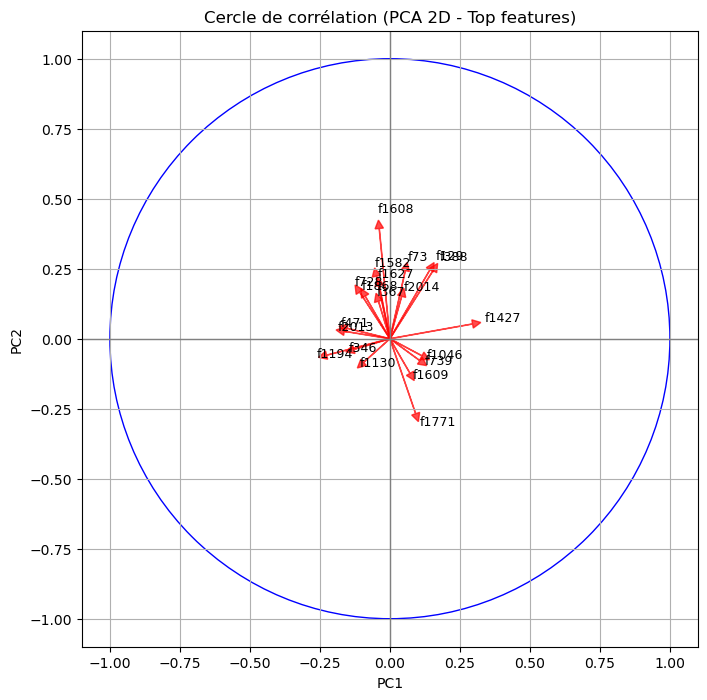

In [20]:
# =========================
# Sélection des features importantes
# =========================
n_features_display = 20

components = pca_2d.components_

# Importance = contribution sur PC1 + PC2
importance = np.abs(components[0]) + np.abs(components[1])

# Indices des features les plus importantes
indices = np.argsort(importance)[-n_features_display:]

# =========================
# Plot du cercle de corrélation
# =========================
plt.figure(figsize=(8, 8))

# Cercle unité
circle = plt.Circle((0, 0), 1, color='blue', fill=False)
plt.gca().add_artist(circle)

# Axes
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)

# Vecteurs
for i in indices:
    x = components[0, i]
    y = components[1, i]

    plt.arrow(0, 0, x, y,
              head_width=0.03,
              head_length=0.03,
              color='red',
              alpha=0.7)

    plt.text(x * 1.15, y * 1.15, f"f{i}", fontsize=9)

# Mise en forme
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle de corrélation (PCA 2D - Top features)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

plt.show()

### Interprétation des axes PCA
Dans une analyse en composantes principales classique, le cercle des corrélations permet d’interpréter les relations entre les variables d’origine et les axes principaux.

Dans ce projet, les variables d’origine correspondent aux dimensions des embeddings issus de ResNet50, qui ne sont pas directement interprétables individuellement.

La visualisation ci-dessus montre la contribution de ces dimensions aux deux premières composantes principales.

Même si l’interprétation individuelle des variables est limitée, cette représentation montre que les dimensions issues du CNN contribuent de manière diffuse, sans variable dominante. Cela est cohérent avec des embeddings deep learning, où l’information est répartie sur de nombreuses dimensions.

## 8. Clustering hiérarchique
En complément de KMeans et DBSCAN, on applique un clustering hiérarchique afin d’analyser la structure des données de manière différente.

Contrairement à KMeans, cette méthode ne nécessite pas de fixer le nombre de clusters à l’avance et permet de visualiser la structure des regroupements sous forme de dendrogramme.

Cela permet d’explorer les relations de similarité entre les observations à différents niveaux de granularité.

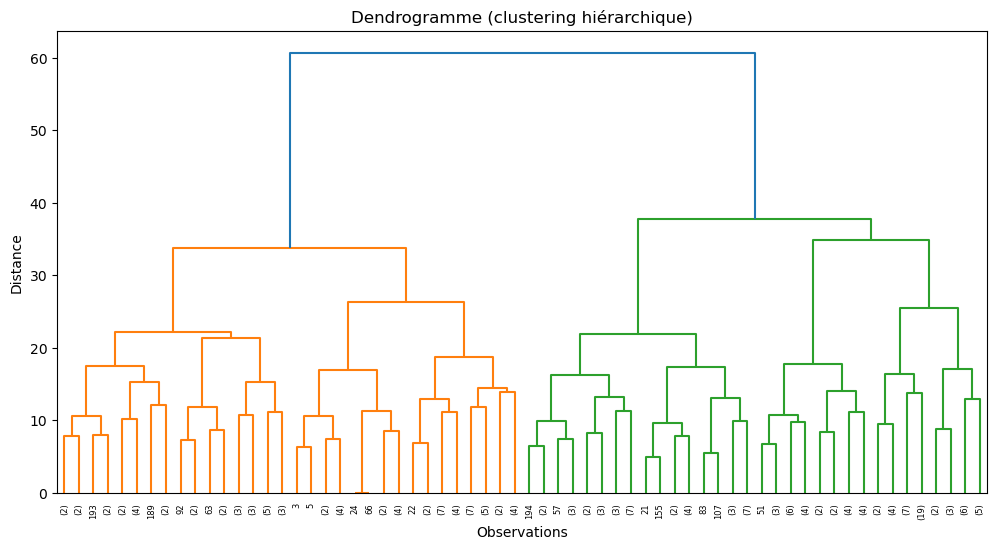

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# On prend un sous-échantillon pour lisibilité
np.random.seed(42)
sample_size = 200
sample_idx = np.random.choice(len(features_pca), sample_size, replace=False)

X_sample = features_pca[sample_idx]

# Clustering hiérarchique
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogramme (clustering hiérarchique)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

### Interprétation du dendrogramme
Le dendrogramme représente la manière dont les observations sont regroupées progressivement en clusters.

Chaque fusion correspond à un regroupement de deux groupes d’observations en fonction de leur similarité.

La hauteur des branches indique la distance entre les groupes :
- des fusions à faible hauteur indiquent des observations très similaires ;
- des fusions à grande hauteur indiquent des regroupements plus hétérogènes.

On observe ici que certaines branches se regroupent rapidement, ce qui suggère l’existence de groupes naturels dans les données.

Cependant, le dendrogramme devient rapidement difficile à lire lorsque le nombre d’observations est élevé, ce qui limite son utilisation pratique à des sous-échantillons.

Cette analyse complète l’approche KMeans en apportant une vision hiérarchique de la structure des données.

## 9. Projection en 3 dimensions pour visualisation
Afin de visualiser la structure des données, on réalise une seconde réduction de dimension pour projeter les embeddings en 3 dimensions.

Cette projection permettra d’observer visuellement la séparation entre les différentes catégories d’images.

In [22]:
pca_3d = PCA(n_components=3)
features_3d = pca_3d.fit_transform(features_pca)

print("Shape 3D :", features_3d.shape)

Shape 3D : (1506, 3)


In [23]:
import plotly.graph_objects as go

# Masques pour chaque classe
mask_cancer = labels == "cancer"
mask_normal = labels == "normal"
mask_unlabeled = labels == "unlabeled"

fig = go.Figure()

# Unlabeled (transparent)
fig.add_trace(go.Scatter3d(
    x=features_3d[mask_unlabeled, 0],
    y=features_3d[mask_unlabeled, 1],
    z=features_3d[mask_unlabeled, 2],
    mode='markers',
    marker=dict(
        size=3,
        color='gray',
        opacity=0.5  # transparent
    ),
    name='unlabeled'
))

# Cancer (visible)
fig.add_trace(go.Scatter3d(
    x=features_3d[mask_cancer, 0],
    y=features_3d[mask_cancer, 1],
    z=features_3d[mask_cancer, 2],
    mode='markers',
    marker=dict(
        size=5,
        color='red',
        opacity=1
    ),
    name='cancer'
))

# Normal (visible)
fig.add_trace(go.Scatter3d(
    x=features_3d[mask_normal, 0],
    y=features_3d[mask_normal, 1],
    z=features_3d[mask_normal, 2],
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=1
    ),
    name='normal'
))

fig.update_layout(
    title="Visualisation 3D des embeddings (PCA)",
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()

### Bilan de la projection 3D
La projection en 3 dimensions permet de visualiser la structure des embeddings.

La visualisation en 3D montre une structuration des données avec deux groupes principaux, ce qui suggère que les embeddings capturent des caractéristiques pertinentes. Toutefois, la séparation n’est pas parfaite, ce qui justifie l’utilisation de méthodes de clustering et d’apprentissage semi-supervisé.

Cette structure sera exploitée dans l’étape suivante pour effectuer un clustering et générer des pseudo-labels.

## 10. Choix du nombre de clusters (K)
Afin de déterminer le nombre de clusters optimal pour KMeans, on teste plusieurs valeurs de K.

On évalue chaque configuration à l’aide de deux métriques :
- l’inertie (méthode du coude)
- le score de silhouette

Cela permet d’identifier une valeur de K pertinente pour la structure des données.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(features_pca)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_pca, labels_k))

    print(f"K={k} | inertia={kmeans.inertia_:.2f} | silhouette={silhouettes[-1]:.4f}")

K=2 | inertia=77631.34 | silhouette=0.1419
K=3 | inertia=71858.20 | silhouette=0.1276
K=4 | inertia=67763.34 | silhouette=0.1183
K=5 | inertia=64154.03 | silhouette=0.1262
K=6 | inertia=61589.82 | silhouette=0.1233
K=7 | inertia=59409.99 | silhouette=0.1305
K=8 | inertia=57406.12 | silhouette=0.1373
K=9 | inertia=55831.96 | silhouette=0.1323
K=10 | inertia=54377.73 | silhouette=0.1360
K=11 | inertia=53035.17 | silhouette=0.1362
K=12 | inertia=51664.64 | silhouette=0.1339
K=13 | inertia=50859.28 | silhouette=0.1301
K=14 | inertia=50161.26 | silhouette=0.1216
K=15 | inertia=49477.45 | silhouette=0.1232


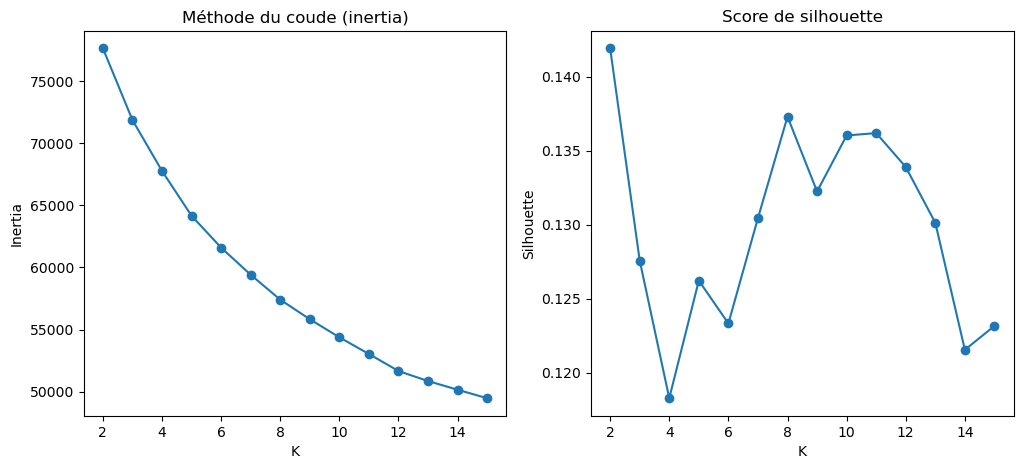

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Elbow
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title("Méthode du coude (inertia)")
plt.xlabel("K")
plt.ylabel("Inertia")

# Silhouette
plt.subplot(1,2,2)
plt.plot(K_range, silhouettes, marker='o')
plt.title("Score de silhouette")
plt.xlabel("K")
plt.ylabel("Silhouette")

plt.show()

### Bilan du choix de K
L’analyse de l’inertie ne fait pas apparaître de coude très marqué, ce qui suggère que la structure des données n’est pas triviale.

Le score de silhouette est maximal pour K=2, ce qui est cohérent avec la présence de deux classes métier principales. Toutefois, des valeurs plus élevées comme K=5 ou K=8 restent intéressantes pour explorer d’éventuelles sous-structures dans les embeddings.

On retient donc plusieurs valeurs candidates de K pour la suite de l’analyse, en combinant les métriques quantitatives et l’interprétation métier.

## 11. Clustering avec KMeans
Suite à l’analyse des métriques (inertie et silhouette), on teste plusieurs valeurs de K (2, 10 et 11).

L’objectif est de comparer visuellement la structuration des données pour différentes granularités, et d’identifier la configuration la plus pertinente pour la suite du projet.

In [26]:
from sklearn.cluster import KMeans

k_values = [2, 10, 11]
cluster_results = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_pca)
    cluster_results[k] = cluster_labels

    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    print(f"\nK={k}")
    for label, count in zip(unique_labels, counts):
        print(f"  Cluster {label}: {count} points")


K=2
  Cluster 0: 674 points
  Cluster 1: 832 points

K=10
  Cluster 0: 92 points
  Cluster 1: 203 points
  Cluster 2: 146 points
  Cluster 3: 148 points
  Cluster 4: 63 points
  Cluster 5: 273 points
  Cluster 6: 142 points
  Cluster 7: 163 points
  Cluster 8: 109 points
  Cluster 9: 167 points

K=11
  Cluster 0: 168 points
  Cluster 1: 167 points
  Cluster 2: 145 points
  Cluster 3: 99 points
  Cluster 4: 143 points
  Cluster 5: 142 points
  Cluster 6: 56 points
  Cluster 7: 74 points
  Cluster 8: 284 points
  Cluster 9: 139 points
  Cluster 10: 89 points


In [27]:
import plotly.graph_objects as go

def plot_clusters_3d(features_3d, cluster_labels, title):
    fig = go.Figure()

    unique_clusters = np.unique(cluster_labels)

    for cluster in unique_clusters:
        mask = cluster_labels == cluster

        fig.add_trace(go.Scatter3d(
            x=features_3d[mask, 0],
            y=features_3d[mask, 1],
            z=features_3d[mask, 2],
            mode="markers",
            marker=dict(size=4),
            name=f"Cluster {cluster}"
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        )
    )

    fig.show()

In [28]:
plot_clusters_3d(features_3d, cluster_results[2], "KMeans avec K=2")

In [29]:
plot_clusters_3d(features_3d, cluster_results[10], "KMeans avec K=10")

In [30]:
plot_clusters_3d(features_3d, cluster_results[11], "KMeans avec K=11")

## 12. Clustering avec DBSCAN

In [31]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan.fit_predict(features_pca)

unique_labels, counts = np.unique(db_labels, return_counts=True)

print("Résultat DBSCAN :")
for label, count in zip(unique_labels, counts):
    print(f"  Label {label}: {count} points")

Résultat DBSCAN :
  Label -1: 1506 points


In [32]:
plot_clusters_3d(features_3d, db_labels, "DBSCAN")

## 13. Comparaison avec les labels
Après avoir visualisé les clusters obtenus par KMeans, on superpose les données labellisées afin d’évaluer la cohérence entre la structure trouvée de manière non supervisée et les classes réelles disponibles.

Cette visualisation ne sert pas à construire le clustering, mais à l’interpréter et à comparer différentes valeurs de K.

In [33]:
import plotly.graph_objects as go
import numpy as np

def plot_clusters_with_labeled_overlay(features_3d, cluster_labels, cancer_idx, normal_idx, title):
    fig = go.Figure()

    unique_clusters = np.unique(cluster_labels)

    # 1. Tous les points, colorés par cluster
    for cluster in unique_clusters:
        mask = cluster_labels == cluster

        fig.add_trace(go.Scatter3d(
            x=features_3d[mask, 0],
            y=features_3d[mask, 1],
            z=features_3d[mask, 2],
            mode="markers",
            marker=dict(
                size=3,
                opacity=0.5
            ),
            name=f"Cluster {cluster}"
        ))

    # 2. Overlay des points labellisés cancer
    fig.add_trace(go.Scatter3d(
        x=features_3d[cancer_idx, 0],
        y=features_3d[cancer_idx, 1],
        z=features_3d[cancer_idx, 2],
        mode="markers",
        marker=dict(
            size=6,
            color="red",
            opacity=1,
            symbol="circle"
        ),
        name="Cancer (label réel)"
    ))

    # 3. Overlay des points labellisés normal
    fig.add_trace(go.Scatter3d(
        x=features_3d[normal_idx, 0],
        y=features_3d[normal_idx, 1],
        z=features_3d[normal_idx, 2],
        mode="markers",
        marker=dict(
            size=6,
            color="blue",
            opacity=1,
            symbol="diamond"
        ),
        name="Normal (label réel)"
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3"
        )
    )

    fig.show()

In [34]:
plot_clusters_with_labeled_overlay(
    features_3d,
    cluster_results[2],
    cancer_idx,
    normal_idx,
    title="KMeans K=2 avec superposition des labels réels"
)

In [35]:
plot_clusters_with_labeled_overlay(
    features_3d,
    cluster_results[11],
    cancer_idx,
    normal_idx,
    title="KMeans K=10 avec superposition des labels réels"
)

In [36]:
plot_clusters_with_labeled_overlay(
    features_3d,
    cluster_results[11],
    cancer_idx,
    normal_idx,
    title="KMeans K=11 avec superposition des labels réels"
)

In [37]:
from sklearn.metrics import adjusted_rand_score
import numpy as np

print("=== Évaluation clustering (ARI) ===\n")

# =========================
# Filtrer uniquement les données labellisées
# =========================
mask_labeled = true_labels != "unlabeled"
cluster_labels_final = cluster_results[2]

y_true = true_labels[mask_labeled]
kmeans_pred = cluster_labels_final[mask_labeled]

# =========================
# KMEANS
# =========================
ari_kmeans = adjusted_rand_score(y_true, kmeans_pred)
print(f"ARI KMeans : {ari_kmeans:.4f}")

# =========================
# DBSCAN
# =========================
dbscan_pred = db_labels[mask_labeled]

# enlever le bruit (-1)
mask_dbscan = dbscan_pred != -1

if np.sum(mask_dbscan) > 0:
    ari_dbscan = adjusted_rand_score(
        y_true[mask_dbscan],
        dbscan_pred[mask_dbscan]
    )
    print(f"ARI DBSCAN (sans bruit) : {ari_dbscan:.4f}")
else:
    print("ARI DBSCAN : impossible (tout est bruit)")

=== Évaluation clustering (ARI) ===

ARI KMeans : 0.4851
ARI DBSCAN : impossible (tout est bruit)


## Conclusion et perspectives
Le clustering a été réalisé sur l’ensemble des données dans une démarche exploratoire, afin d’exploiter pleinement la structure des embeddings extraits avec ResNet50.

**KMeans avec 𝐾=2** permet d’obtenir une séparation globalement cohérente avec les classes réelles (cancer vs normal), bien que cette séparation reste imparfaite. Cela montre que les embeddings capturent une information discriminante, sans être spécifiquement optimisés pour cette tâche de classification.

**Lorsque le nombre de clusters augmente (𝐾=5, 𝐾=8)**, des sous-groupes émergent. Toutefois, ceux-ci ne correspondent plus directement aux classes cibles, mais reflètent plutôt des variations intra-classe au sein des données.

Par ailleurs, DBSCAN ne permet pas d’identifier de clusters exploitables dans ce contexte. Ce résultat suggère l’absence de structure de densité locale marquée dans l’espace des embeddings.

Enfin, pour la phase semi-supervisée, un protocole plus rigoureux sera mis en place : le mapping entre clusters et labels sera construit uniquement à partir d’un sous-ensemble d’entraînement labellisé, puis évalué sur un ensemble de test distinct.

In [38]:
# Exports pour Semi-supervisé

K_final = 2
cluster_labels_final = cluster_results[K_final]

np.save("../data/features.npy", features)
np.save("../data/true_labels.npy", true_labels)
np.save("../data/image_paths.npy", np.array(image_paths, dtype=object))
np.save("../data/features_pca.npy", features_pca)
np.save("../data/cluster_labels_final.npy", cluster_labels_final)